In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
from scipy import optimize
from scipy.optimize import curve_fit
import sympy as sym
from sympy import *
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


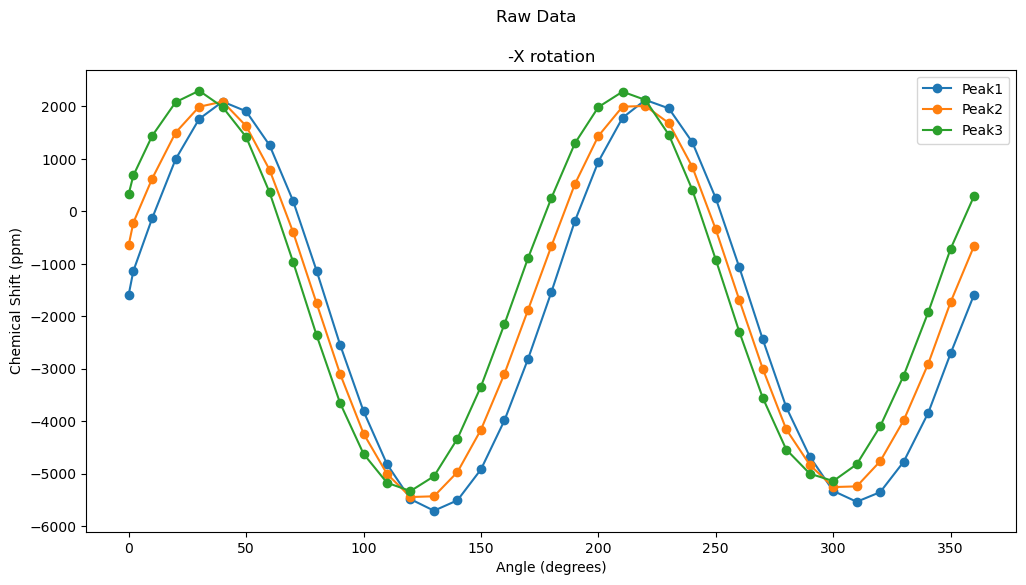

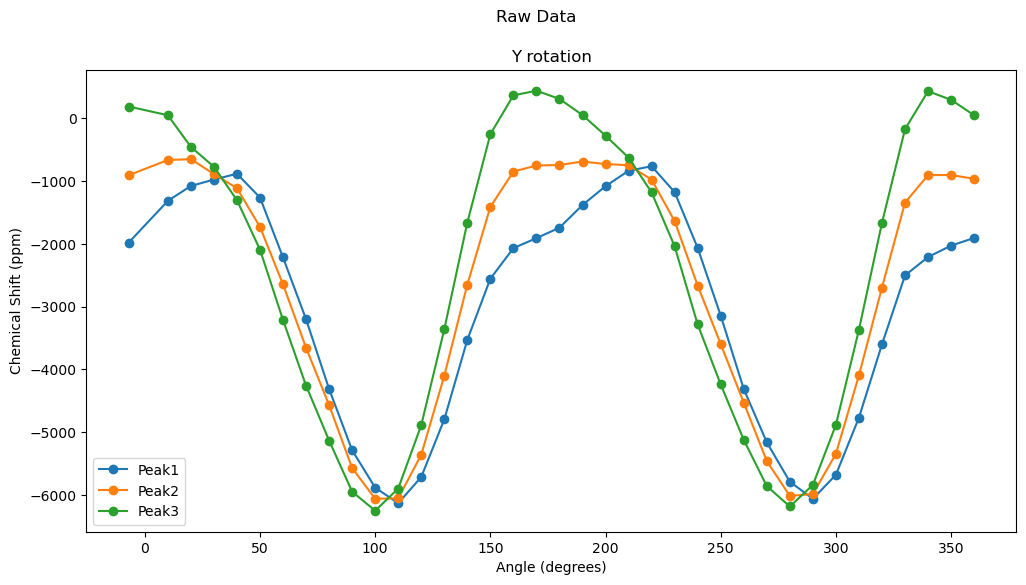

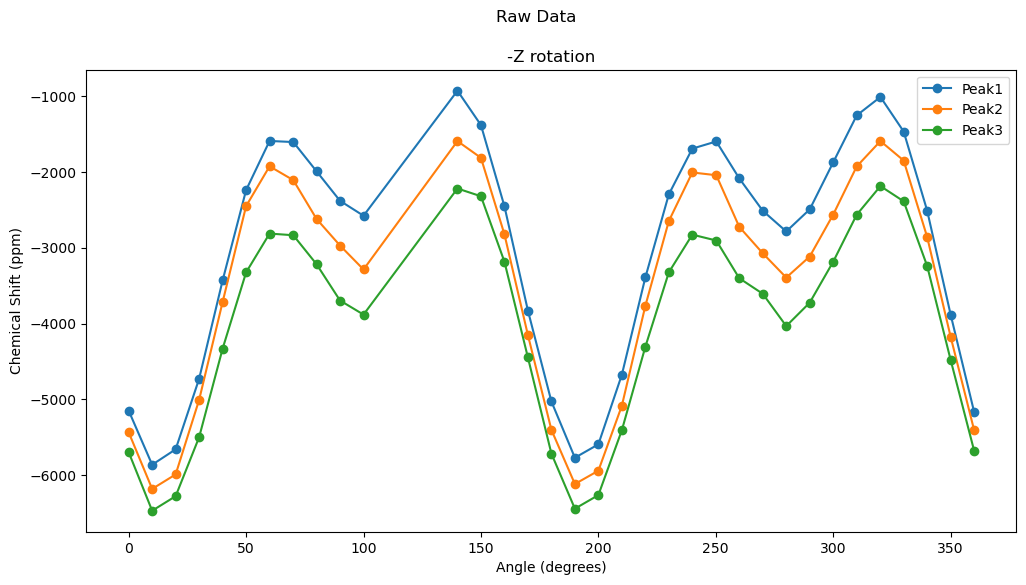

In [2]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster1Peak0 = df[i].Cluster1Peak0*w0
    df[i].Cluster1Peak1 = df[i].Cluster1Peak1*w0
    df[i].Cluster1Peak2 = df[i].Cluster1Peak2*w0

    # print(df[i].Cluster1Peak1)
    plt.figure(figsize=(12, 6))


    plt.plot(df[i].Angle, df[i].Cluster1Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (ppm)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

In [3]:
freq_sum = [0]*3
freq_diff = [0]*3
for i in range(3):

    freq_sum[i] = df[i].Cluster1Peak0 + df[i].Cluster1Peak1 + df[i].Cluster1Peak2
    freq_diff[i] = df[i].Cluster1Peak0 - df[i].Cluster1Peak2

[ -356.74185704 -1467.78980839   624.21405175]


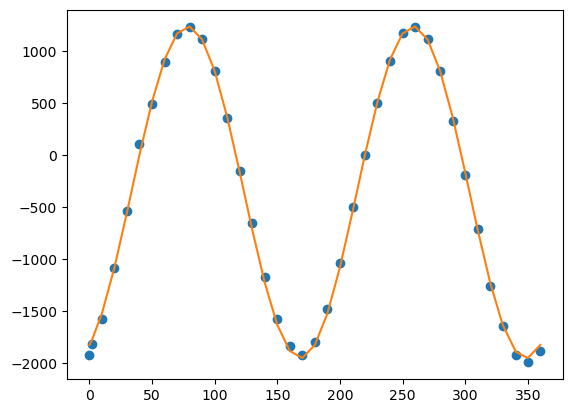

[ -586.0506105  -1336.89762528  1165.32885478]


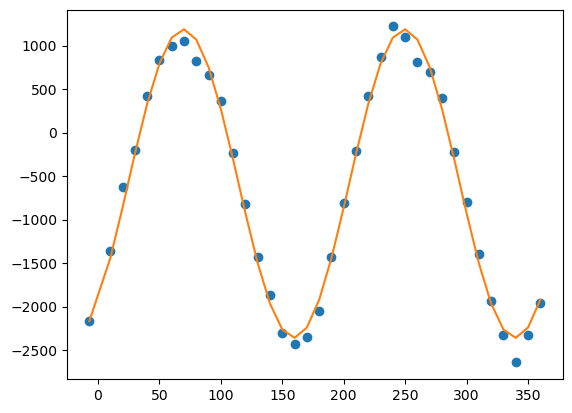

[1001.05864936 -354.09882888  -88.00591198]


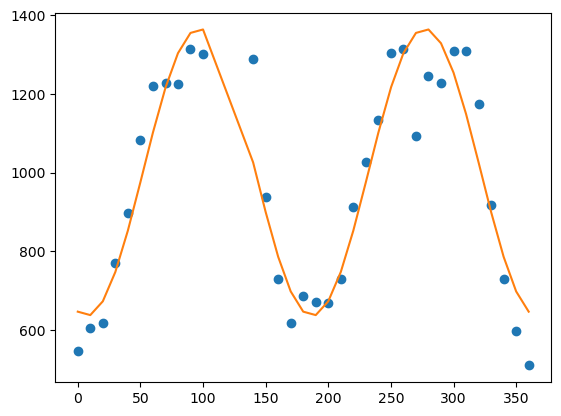

In [4]:
for i in range(3):
    params, pcov = curve_fit(fourier3, df[i].Angle, freq_diff[i])
    print(params)
    plt.plot(df[i].Angle, freq_diff[i], "o")
    plt.plot(df[i].Angle, fourier3(df[i].Angle, params[0], params[1], params[2]))
    plt.show()